In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [27]:
df = pd.read_csv('training_data - training_data.csv', index_col=0)

# Описание задания

Вам необходимо построить модель-классификатор по определению диабета. У вас нет никаких ограничений по инструментам, новым полям и способу энкодинга данных.

# О данных

Датасет представляет собой набор медицинских и демографических данных пациентов, а также их диагноз по диабету (положительный или отрицательный). 

Данные включают такие характеристики, как возраст, пол, индекс массы тела (BMI), гипертония, болезни сердца, история курения, уровень HbA1c и уровень глюкозы в крови. Этот набор данных можно использовать для создания моделей машинного обучения для прогнозирования диабета у пациентов на основе их истории болезни и демографической информации.

# Submission задания

Вам будет предоставлен второй датасет, без целевой переменной (таргет - diabetes)
Этот датасет необходимо будет проскорить и сабмитнуть в Google Classroom в формате .csv, с 2 стобцами: `ID` и `prediction`

Поле `prediction` должно быть предсказанием **<span style = 'color : green'> класса </span>** (`predict`), т.е. 1 или 0 а **<span style = 'color : red'>не вероятности </span>** (`predict_proba`)

In [21]:
df_test = pd.read_csv('test_data - test_data.csv', index_col=0)

In [26]:
df_test

,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,ba0d6256-ca6e-46a7-a2fb-2518a8937fd7,Female,60.0,1,0,former,23.77,4.8,130
1,7102b1ab-c7a4-4a43-b1fc-cb588d0553b8,Male,2.0,0,0,No Info,15.19,5.0,159
2,51ba207e-4934-41b4-a31c-cd275c5ca555,Female,74.0,0,0,not current,39.59,6.5,160
3,7e17faaa-0402-4728-9719-83982eba3afd,Female,51.0,0,0,never,26.67,6.6,80
4,08b4e515-286e-4393-9a55-138962f9546e,Male,35.0,0,0,never,26.09,3.5,159
...,...,...,...,...,...,...,...,...,...
26141,1f8db6fe-03f8-48ca-9a42-9f12062b002d,Female,31.0,0,0,never,27.32,6.1,140
26142,5bf3ca1a-ced5-474b-a354-cc3bec9f16d3,Female,65.0,1,1,never,27.25,5.7,100
26143,930e6345-a920-47dd-abd0-6bc0be2ae56f,Male,30.0,1,0,former,57.17,5.8,300
26144,035f3cc4-e8af-448a-8172-a1b027e06de1,Male,20.0,0,0,never,32.70,6.2,159


In [6]:
df.head()

,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,78830894-cdd8-43d1-9655-03db74141b7a,Female,80.0,0,1,never,25.19,6.6,140,0
1,32262c0e-903a-46b8-9061-b1a2f5a3e9b2,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,c4868b73-ca90-48ed-af14-3d1f78a5f030,Male,28.0,0,0,never,27.32,5.7,158,0
3,bec2ef91-5aff-48df-ac16-cb210b5f29fa,Female,36.0,0,0,current,23.45,5.0,155,0
4,1a6852a8-ee80-4d93-bea0-f0cdd941dc3d,Male,76.0,1,1,current,20.14,4.8,155,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73718 entries, 0 to 73717
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   73718 non-null  str    
 1   gender               73718 non-null  str    
 2   age                  73718 non-null  float64
 3   hypertension         73718 non-null  int64  
 4   heart_disease        73718 non-null  int64  
 5   smoking_history      73718 non-null  str    
 6   bmi                  73718 non-null  float64
 7   HbA1c_level          73718 non-null  float64
 8   blood_glucose_level  73718 non-null  int64  
 9   diabetes             73718 non-null  int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 5.6 MB


In [12]:
df.shape

(73718, 10)

In [8]:
df.isna().sum()

ID                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [14]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 26146 entries, 0 to 26145
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   26146 non-null  str    
 1   gender               26146 non-null  str    
 2   age                  26146 non-null  float64
 3   hypertension         26146 non-null  int64  
 4   heart_disease        26146 non-null  int64  
 5   smoking_history      26146 non-null  str    
 6   bmi                  26146 non-null  float64
 7   HbA1c_level          26146 non-null  float64
 8   blood_glucose_level  26146 non-null  int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 1.8 MB


In [13]:
df_test.shape

(26146, 9)

In [9]:
df_test.isna().sum()

ID                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64

In [10]:
df_test

,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,ba0d6256-ca6e-46a7-a2fb-2518a8937fd7,Female,60.0,1,0,former,23.77,4.8,130
1,7102b1ab-c7a4-4a43-b1fc-cb588d0553b8,Male,2.0,0,0,No Info,15.19,5.0,159
2,51ba207e-4934-41b4-a31c-cd275c5ca555,Female,74.0,0,0,not current,39.59,6.5,160
3,7e17faaa-0402-4728-9719-83982eba3afd,Female,51.0,0,0,never,26.67,6.6,80
4,08b4e515-286e-4393-9a55-138962f9546e,Male,35.0,0,0,never,26.09,3.5,159
...,...,...,...,...,...,...,...,...,...
26141,1f8db6fe-03f8-48ca-9a42-9f12062b002d,Female,31.0,0,0,never,27.32,6.1,140
26142,5bf3ca1a-ced5-474b-a354-cc3bec9f16d3,Female,65.0,1,1,never,27.25,5.7,100
26143,930e6345-a920-47dd-abd0-6bc0be2ae56f,Male,30.0,1,0,former,57.17,5.8,300
26144,035f3cc4-e8af-448a-8172-a1b027e06de1,Male,20.0,0,0,never,32.70,6.2,159


In [11]:
df

,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,78830894-cdd8-43d1-9655-03db74141b7a,Female,80.0,0,1,never,25.19,6.6,140,0
1,32262c0e-903a-46b8-9061-b1a2f5a3e9b2,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,c4868b73-ca90-48ed-af14-3d1f78a5f030,Male,28.0,0,0,never,27.32,5.7,158,0
3,bec2ef91-5aff-48df-ac16-cb210b5f29fa,Female,36.0,0,0,current,23.45,5.0,155,0
4,1a6852a8-ee80-4d93-bea0-f0cdd941dc3d,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...,...
73713,5c890971-a6d7-44ce-a8a1-3b38cda7ef3b,Female,70.0,1,0,never,55.57,6.2,130,1
73714,13a8f177-1623-4acf-9db8-1e8ac8577c86,Male,60.0,0,0,No Info,27.32,6.6,160,0
73715,c9539d1b-075f-481f-8ae4-ab9bba75af5b,Male,65.0,0,0,former,32.07,5.0,160,0
73716,08eb5a8d-f577-440a-9408-c6d99ca17204,Male,64.0,0,0,current,30.23,6.2,158,0


In [5]:
df['diabetes'].value_counts()

diabetes
0    67168
1     6550
Name: count, dtype: int64

In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,73718.000000,73718.000000,73718.000000,73718.000000,73718.000000,73718.000000,73718.000000
mean,41.852959,0.078963,0.040858,27.348037,5.534038,138.197835,0.088852
std,22.488153,0.269683,0.197963,6.776093,1.070917,40.892972,0.284532
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.430000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.900000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(3718)

In [9]:
df[df.duplicated()]['diabetes'].value_counts()

diabetes
0    3368
1     350
Name: count, dtype: int64

In [11]:
df[['gender', 'smoking_history', 'hypertension', 'heart_disease']].nunique()

gender             3
smoking_history    6
hypertension       2
heart_disease      2
dtype: int64

In [17]:
print(df['gender'].value_counts())
print()

print(df['smoking_history'].value_counts())
print()

print(df['hypertension'].value_counts())
print()

print(df['heart_disease'].value_counts())

gender
Female    43097
Male      30609
Other        12
Name: count, dtype: int64

smoking_history
never          26296
No Info        25236
former          7150
current         7035
not current     4958
ever            3043
Name: count, dtype: int64

hypertension
0    67897
1     5821
Name: count, dtype: int64

heart_disease
0    70706
1     3012
Name: count, dtype: int64


In [71]:
x = df.drop(['ID', 'diabetes'], axis=1)
y = df['diabetes']

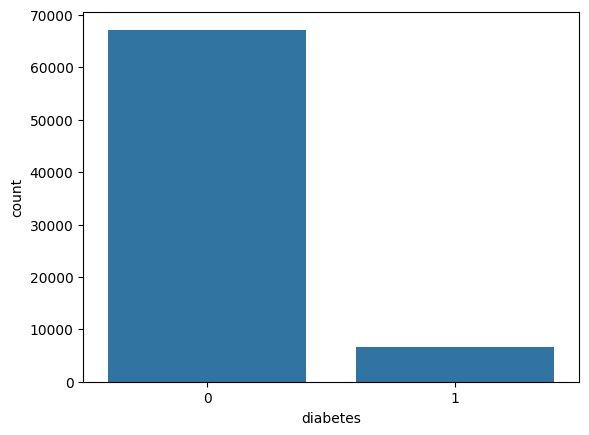

In [72]:
sns.countplot(data=df, x="diabetes")
plt.show()

In [38]:
corr = df.corr(numeric_only=True)

<Axes: >

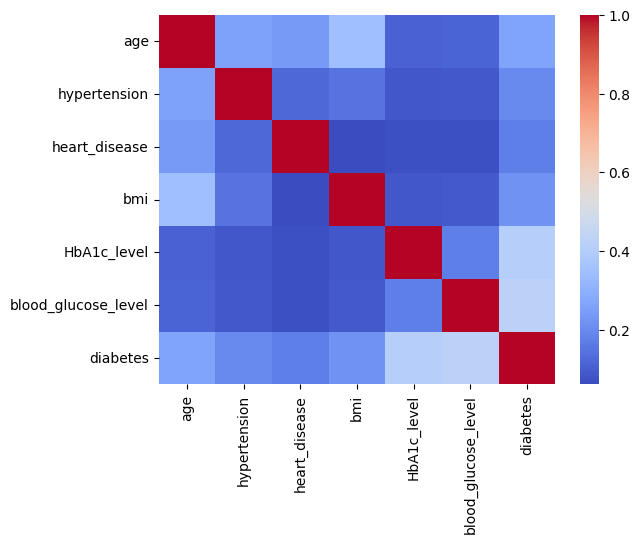

In [40]:
sns.heatmap(corr, cmap = "coolwarm")

In [41]:
corr['diabetes'].sort_values()

heart_disease          0.174454
hypertension           0.199908
bmi                    0.216711
age                    0.264927
HbA1c_level            0.406207
blood_glucose_level    0.423795
diabetes               1.000000
Name: diabetes, dtype: float64

In [73]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [74]:
x_train.dtypes

gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
dtype: object

In [75]:
cat_cols = ['gender', 'smoking_history']

num_cols = [
    'age',
    'hypertension',
    'heart_disease',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

In [76]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [77]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=7))
])

In [78]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [79]:
y_pred = pipeline.predict(x_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9594411285946826
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13434
           1       0.86      0.65      0.74      1310

    accuracy                           0.96     14744
   macro avg       0.91      0.82      0.86     14744
weighted avg       0.96      0.96      0.96     14744



In [80]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [89]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

knn_model = Pipeline([
            ('preprocessor', preprocessor),
            ('model', KNeighborsClassifier(n_neighbors=7))
        ])


tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

In [83]:
x_train.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
57430,Male,60.0,0,0,current,23.42,5.7,130
10605,Female,35.0,0,0,former,29.32,6.6,90
5951,Male,21.0,0,0,never,23.38,4.0,100
48396,Female,16.0,0,0,No Info,24.05,4.0,130
53068,Male,54.0,0,0,never,33.64,6.1,80


In [90]:
log_model.fit(x_train, y_train)
knn_model.fit(x_train, y_train)
tree_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [92]:
pred = log_model.predict(x_test)
pred1 = knn_model.predict(x_test)
pred2 = tree_model.predict(x_test)
pred3 = rf_model.predict(x_test)

In [93]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13434
           1       0.86      0.65      0.74      1310

    accuracy                           0.96     14744
   macro avg       0.91      0.82      0.86     14744
weighted avg       0.96      0.96      0.96     14744



In [94]:
print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     13434
           1       0.90      0.61      0.73      1310

    accuracy                           0.96     14744
   macro avg       0.93      0.80      0.85     14744
weighted avg       0.96      0.96      0.96     14744



In [95]:
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     13434
           1       1.00      0.68      0.81      1310

    accuracy                           0.97     14744
   macro avg       0.98      0.84      0.90     14744
weighted avg       0.97      0.97      0.97     14744



In [96]:
print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     13434
           1       0.96      0.72      0.82      1310

    accuracy                           0.97     14744
   macro avg       0.97      0.86      0.90     14744
weighted avg       0.97      0.97      0.97     14744



In [98]:
df_test.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
count,26146.000000,26146.000000,26146.000000,26146.000000,26146.000000,26146.000000
mean,41.731139,0.074772,0.040924,27.277072,5.527962,138.451274
std,22.412588,0.263029,0.198118,6.745570,1.079653,40.949566
min,0.080000,0.000000,0.000000,10.190000,3.500000,80.000000
25%,24.000000,0.000000,0.000000,23.350000,4.800000,100.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000
75%,59.000000,0.000000,0.000000,29.790000,6.200000,159.000000
max,80.000000,1.000000,1.000000,91.820000,9.000000,300.000000


In [99]:
df_test.duplicated().sum()

np.int64(0)

In [100]:
df_test[['gender', 'smoking_history', 'hypertension', 'heart_disease']].nunique()

gender             3
smoking_history    6
hypertension       2
heart_disease      2
dtype: int64

In [101]:
print(df_test['gender'].value_counts())
print()

print(df_test['smoking_history'].value_counts())
print()

print(df_test['hypertension'].value_counts())
print()

print(df_test['heart_disease'].value_counts())

gender
Female    15200
Male      10940
Other         6
Name: count, dtype: int64

smoking_history
never          9388
No Info        8930
current        2534
former         2512
not current    1683
ever           1099
Name: count, dtype: int64

hypertension
0    24191
1     1955
Name: count, dtype: int64

heart_disease
0    25076
1     1070
Name: count, dtype: int64


In [105]:
x_full = df.drop(['ID', 'diabetes'], axis=1)
y_full = df['diabetes']

rf_model.fit(x_full, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [106]:
x_final = df_test.drop(['ID'], axis=1)

In [107]:
predictions = rf_model.predict(x_final)

In [108]:
predictions

array([0, 0, 0, ..., 1, 0, 0], shape=(26146,))

In [109]:
submission = pd.DataFrame({
    'ID': df_test['ID'],
    'prediction': predictions
})

In [110]:
submission.head()

,ID,prediction
0,ba0d6256-ca6e-46a7-a2fb-2518a8937fd7,0
1,7102b1ab-c7a4-4a43-b1fc-cb588d0553b8,0
2,51ba207e-4934-41b4-a31c-cd275c5ca555,0
3,7e17faaa-0402-4728-9719-83982eba3afd,0
4,08b4e515-286e-4393-9a55-138962f9546e,0


In [111]:
submission.to_csv('submission.csv', index=False)

In [125]:
submission.head(14)

,ID,prediction
0,ba0d6256-ca6e-46a7-a2fb-2518a8937fd7,0
1,7102b1ab-c7a4-4a43-b1fc-cb588d0553b8,0
2,51ba207e-4934-41b4-a31c-cd275c5ca555,0
3,7e17faaa-0402-4728-9719-83982eba3afd,0
4,08b4e515-286e-4393-9a55-138962f9546e,0
5,ae8c742d-47f9-4aa8-b246-8309430bcf8d,0
6,6a840d8c-d7d8-49c6-8412-4a6dd8f2cbd0,0
7,1e51ca84-e391-4f90-b225-cb0cdc3508a5,0
8,ba9513a6-6f18-44de-a46e-f308b13d6905,0
9,b7843957-4835-4612-a922-6e964a7c0dd3,0


In [123]:
submission[submission["prediction"] == 1]


,ID,prediction
13,e95f923a-a1d5-4634-ae27-bf2f04953a0a,1
24,86a98248-ca82-4b8b-aa14-bae8fae49763,1
47,f44e7785-9bd8-4429-aef5-7964a4ae4ce5,1
84,48108b57-106a-4a11-abea-b98cdaf25a3c,1
90,04b80d23-694e-4b7a-be06-746a20933982,1
...,...,...
26107,49ef96be-8916-4fc0-8eda-6dbe07f9ae33,1
26116,464d979f-583c-4cf7-bd97-6778e99f3b0e,1
26117,3d817df9-f03a-4f6e-a7b5-4e96e5fd59c4,1
26121,293e24f3-7ac7-4d95-86c2-95d2bb835f1a,1
